In [1]:
import os

# Step up to project root so all paths still work
os.chdir('..')
print("Working directory:", os.getcwd())

Working directory: /Users/jamespham/PycharmProjects/ekg_analyzer


In [38]:
import sys
!{sys.executable} -m pip install scikit-learn imbalanced-learn matplotlib numpy pandas seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, 
                             confusion_matrix, 
                             roc_auc_score)
from imblearn.over_sampling import SMOTE

%matplotlib inline

In [39]:
beats  = np.load('./data/processed/beats.npy')
labels = np.load('./data/processed/labels.npy', allow_pickle=True)

print("Beats shape:", beats.shape)
print("Label distribution:", Counter(labels))

Beats shape: (33724, 216)
Label distribution: Counter({np.str_('N'): 23223, np.str_('L'): 4600, np.str_('V'): 3187, np.str_('/'): 1371, np.str_('f'): 660, np.str_('F'): 389, np.str_('A'): 139, np.str_('a'): 116, np.str_('Q'): 25, np.str_('j'): 11, np.str_('S'): 2, np.str_('J'): 1})


In [40]:
# Map detailed beat symbols to broader clinical categories
label_map = {
    'N': 'Normal',       # normal beat
    'L': 'Normal',       # left bundle branch block (keep as normal for now)
    'R': 'Normal',       # right bundle branch block
    'e': 'Normal',       # atrial escape beat
    'j': 'Normal',       # nodal escape beat
    'V': 'PVC',          # premature ventricular contraction
    'E': 'PVC',          # ventricular escape beat
    'A': 'PAC',          # premature atrial contraction
    'a': 'PAC',          # aberrated atrial premature beat
    'J': 'PAC',          # nodal premature beat
    'S': 'PAC',          # supraventricular premature beat
    'F': 'Fusion',       # fusion beat
    '/': 'Paced',        # paced beat
    'f': 'Paced',        # fusion of paced and normal beat
    'Q': 'Unknown',      # unclassifiable beat
}

# Apply the map — anything not in the map gets dropped
mapped = np.array([label_map.get(l, None) for l in labels])

# Keep only beats with a known mapping
# Remove Unknown class — too few samples to learn from
valid_mask = (mapped != None) & (mapped != 'Unknown')
beats_clean  = beats[valid_mask]
labels_clean = mapped[valid_mask]

print("Beats after cleaning:", len(beats_clean))
print("Label distribution:", Counter(labels_clean))

Beats after cleaning: 33699
Label distribution: Counter({np.str_('Normal'): 27834, np.str_('PVC'): 3187, np.str_('Paced'): 2031, np.str_('Fusion'): 389, np.str_('PAC'): 258})


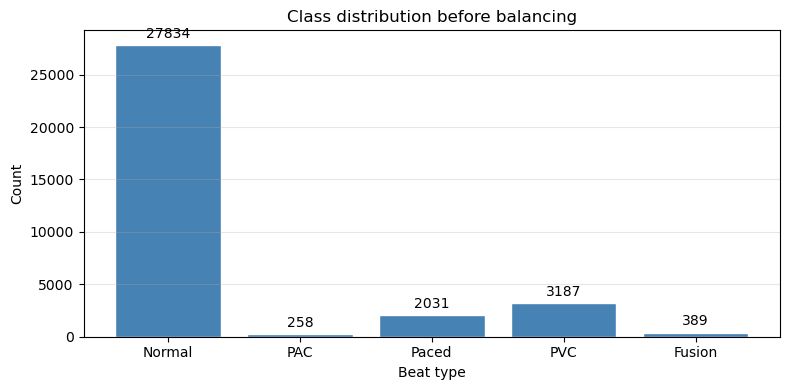

In [41]:
label_counts = Counter(labels_clean)
classes = list(label_counts.keys())
counts  = list(label_counts.values())

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(classes, counts, color='steelblue', edgecolor='white')
ax.bar_label(bars, padding=3)
ax.set_xlabel("Beat type")
ax.set_ylabel("Count")
ax.set_title("Class distribution before balancing")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
# Convert string labels to integers (required by sklearn)
encoder = LabelEncoder()
y = encoder.fit_transform(labels_clean)
X = beats_clean

print("Classes:", list(encoder.classes_))
print("Encoded as:", list(range(len(encoder.classes_))))

# Stratified split — ensures each class appears in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # important: keeps class ratios consistent
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Classes: [np.str_('Fusion'), np.str_('Normal'), np.str_('PAC'), np.str_('PVC'), np.str_('Paced')]
Encoded as: [0, 1, 2, 3, 4]

Training samples: 26959
Testing samples:  6740


In [43]:
# Only apply SMOTE to training data — never to test data
# (test data must reflect real-world distribution)
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", Counter(y_train))
print("After SMOTE: ", Counter(y_train_bal))

Before SMOTE: Counter({np.int64(1): 22267, np.int64(3): 2550, np.int64(4): 1625, np.int64(0): 311, np.int64(2): 206})
After SMOTE:  Counter({np.int64(1): 22267, np.int64(4): 22267, np.int64(3): 22267, np.int64(2): 22267, np.int64(0): 22267})


In [44]:
clf = RandomForestClassifier(
    n_estimators=100,     # number of decision trees
    max_depth=None,       # let trees grow fully
    n_jobs=-1,            # use all CPU cores
    random_state=42
)

clf.fit(X_train_bal, y_train_bal)
print("Training complete.")

Training complete.


In [45]:
y_pred = clf.predict(X_test)

print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(
    y_test, y_pred,
    target_names=encoder.classes_
))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Fusion       0.89      0.85      0.87        78
      Normal       0.99      1.00      0.99      5567
         PAC       0.84      0.62      0.71        52
         PVC       0.97      0.97      0.97       637
       Paced       1.00      1.00      1.00       406

    accuracy                           0.99      6740
   macro avg       0.94      0.89      0.91      6740
weighted avg       0.99      0.99      0.99      6740



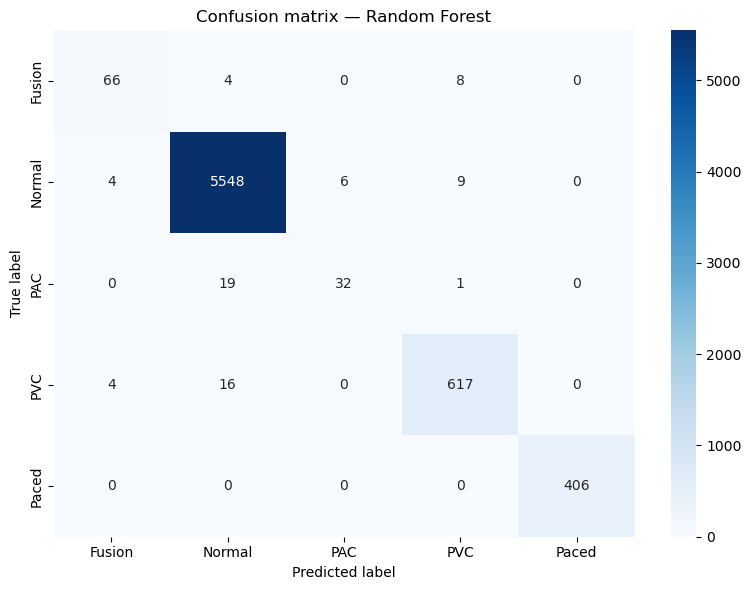

In [46]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    ax=ax
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion matrix — Random Forest")
plt.tight_layout()
plt.show()

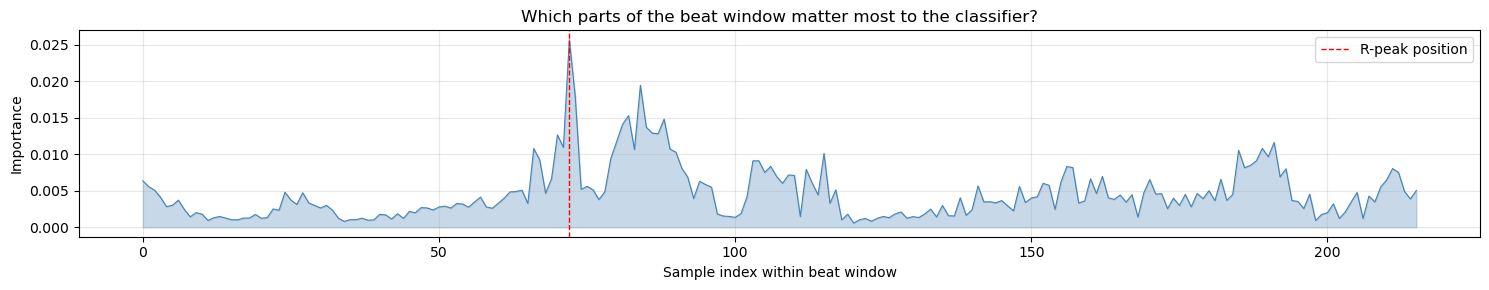

In [47]:
importances = clf.feature_importances_
sample_indices = np.arange(len(importances))

fig, ax = plt.subplots(figsize=(15, 3))
ax.plot(sample_indices, importances, color='steelblue', linewidth=0.8)
ax.fill_between(sample_indices, importances, alpha=0.3, color='steelblue')
ax.axvline(72, color='red', linewidth=1, linestyle='--', label='R-peak position')
ax.set_xlabel("Sample index within beat window")
ax.set_ylabel("Importance")
ax.set_title("Which parts of the beat window matter most to the classifier?")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
import os
import pickle

os.makedirs('./models', exist_ok=True)

# Save the trained model
with open('./models/random_forest.pkl', 'wb') as f:
    pickle.dump(clf, f)

# Save the label encoder (you'll need this to decode predictions later)
with open('./models/label_encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)

# Save the cleaned beats and labels for Phase 4 CNN training
np.save('./data/processed/beats_clean.npy', beats_clean)
np.save('./data/processed/labels_clean.npy', labels_clean)

print("Saved model, encoder, and cleaned data.")

Saved model, encoder, and cleaned data.


In [49]:
print("Unique labels before mapping:", Counter(labels))
print("Unique labels after mapping:", Counter(labels_clean))

Unique labels before mapping: Counter({np.str_('N'): 23223, np.str_('L'): 4600, np.str_('V'): 3187, np.str_('/'): 1371, np.str_('f'): 660, np.str_('F'): 389, np.str_('A'): 139, np.str_('a'): 116, np.str_('Q'): 25, np.str_('j'): 11, np.str_('S'): 2, np.str_('J'): 1})
Unique labels after mapping: Counter({np.str_('Normal'): 27834, np.str_('PVC'): 3187, np.str_('Paced'): 2031, np.str_('Fusion'): 389, np.str_('PAC'): 258})
